# PyTorch Preprocessing - California Housing

This notebook focuses on applying preprocessing using PyTorch as part of the model. In the previous activity, preprocessing was done externally using sklearn, but here it is integrated directly into the model. The goal is to train several neural networks with different hyperparameters and evaluate the best one using the California Housing dataset.

In [1]:
pip install torch tqdm matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.datasets import fetch_california_housing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Load the California Housing dataset the same way as in the previous notebook. It has 8 features and the target "y" represents the median house value

In [3]:
x, y = fetch_california_housing(return_X_y=True, as_frame=True)

x.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


Here the columns that will go through after outlier removal and standar scaling are selected. "Latitude" and "  "Longitude" are excluded since they represent location, so they are kept as they are.

In [4]:
cols = set(x.columns) - {"Longitude", "Latitude"}

First an 80/20 split is done, and then the remaining 20% is split again into two equal parts to get the validation and test sets

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_testval, y_train, y_testval = train_test_split(x, y, test_size=0.2, random_state=42)
x_test, x_val, y_test, y_val = train_test_split(x_testval, y_testval, test_size=0.5, random_state=42)

## Dataset Class

The features are divides into 2 groups:
- x_scale contains 6 numeric features that will go through outlier handling and standar scaling
- x_geo contains "Latitude" and "Longitude", which are left unchanged

The dataset just converts the data into tensors,and the preprocessing is handled inside the model

In [6]:
scale_cols = sorted(cols)
geo_cols   = ['Latitude', 'Longitude']


class HousingDataset(Dataset):
    def __init__(self, df_x: pd.DataFrame, ser_y: pd.Series):
        x_np = df_x.to_numpy(dtype=np.float32)
        y_np = ser_y.to_numpy(dtype=np.float32)

        scale_idx = [df_x.columns.get_loc(c) for c in scale_cols]
        geo_idx   = [df_x.columns.get_loc(c) for c in geo_cols]

        self.x_scale = torch.tensor(x_np[:, scale_idx])
        self.x_geo   = torch.tensor(x_np[:, geo_idx])
        self.y       = torch.tensor(y_np).view(-1, 1)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.x_scale[idx], self.x_geo[idx], self.y[idx]

In [7]:
train_dataset = HousingDataset(x_train, y_train)
val_dataset   = HousingDataset(x_val,   y_val)
test_dataset  = HousingDataset(x_test,  y_test)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=256, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=256, shuffle=False)

## Preprocessing as nn.Module

Before building the model,all preprocessing statistics are computed using only the training data.This helps prevent data leakage, since validation and test sets should not influence these values.

The IQR is used to handle outliers, calculating lower and upper bounds based on the training data. after clipping those values,the mean and standard deviation are calculated, which helps reduce the impact of extreme values on the scaling

In [8]:
Q1  = train_dataset.x_scale.quantile(0.25, dim=0)
Q3  = train_dataset.x_scale.quantile(0.75, dim=0)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x_train_capped = torch.clamp(train_dataset.x_scale, min=lower_bound, max=upper_bound)
mean = x_train_capped.mean(dim=0)
std  = x_train_capped.std(dim=0)

print(f"mean: {mean.tolist()}")
print(f"std : {std.tolist()}")

mean: [1.0585873126983643, 2.89790415763855, 5.313582420349121, 28.60828399658203, 3.813222885131836, 1337.9827880859375]
std : [0.0808103084564209, 0.6906522512435913, 1.2466577291488647, 12.602499008178711, 1.668128490447998, 764.9091796875]


`PreprocessingLayer` takes the preprocessing values and stores them as buffers using "register_buffer()",so they stay with the model but are not updated during training.

In forward(), it clips the features using the training bounds, applies scaling, and then combines them with the geographic features that remain unchanged.

In [9]:
class PreprocessingLayer(nn.Module):
    def __init__(
        self,
        lower_bound: torch.Tensor,
        upper_bound: torch.Tensor,
        mean: torch.Tensor,
        std: torch.Tensor,
    ):
        super().__init__()
        self.register_buffer('lower_bound', lower_bound)
        self.register_buffer('upper_bound', upper_bound)
        self.register_buffer('mean',        mean)
        self.register_buffer('std',         std)

    def forward(self, x_scale: torch.Tensor, x_geo: torch.Tensor) -> torch.Tensor:
        x_capped = torch.clamp(x_scale, min=self.lower_bound, max=self.upper_bound)
        x_scaled = (x_capped - self.mean) / (self.std + 1e-8)
        return torch.cat([x_scaled, x_geo], dim=1)

## Model
The model combines the `PreprocessingLayer` with a feedforward network inside a single `nn.Module`

In [10]:
class HousingModel(nn.Module):
    def __init__(
        self,
        hidden_sizes: list,
        lower_bound: torch.Tensor,
        upper_bound: torch.Tensor,
        mean: torch.Tensor,
        std: torch.Tensor,
        dropout: float = 0.0,
    ):
        super().__init__()
        self.preprocessing = PreprocessingLayer(lower_bound, upper_bound, mean, std)

        input_size = len(scale_cols) + len(geo_cols)
        layers = []
        prev = input_size
        for h in hidden_sizes:
            layers += [nn.Linear(prev, h), nn.ReLU()]
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, 1))

        self.network = nn.Sequential(*layers)

    def forward(self, x_scale: torch.Tensor, x_geo: torch.Tensor) -> torch.Tensor:
        x = self.preprocessing(x_scale, x_geo)
        return self.network(x)

## Training and Evaluation

`evaluate_model` returns metrics which help evaluate and compare the performance of the models

In [11]:
def train_model(model, train_loader, val_loader, lr, epochs):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for x_scale, x_geo, y in train_loader:
            optimizer.zero_grad()
            preds = model(x_scale, x_geo)
            loss  = criterion(preds, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * len(y)
        train_losses.append(running_loss / len(train_loader.dataset))

        model.eval()
        running_val = 0.0
        with torch.no_grad():
            for x_scale, x_geo, y in val_loader:
                preds = model(x_scale, x_geo)
                running_val += criterion(preds, y).item() * len(y)
        val_losses.append(running_val / len(val_loader.dataset))

        if epoch % 25 == 0 or epoch == 1:
            print(f"  Epoch {epoch:>3}/{epochs} | train MSE: {train_losses[-1]:.4f} | val MSE: {val_losses[-1]:.4f}")

    return train_losses, val_losses


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x_scale, x_geo, y in loader:
            all_preds.append(model(x_scale, x_geo))
            all_targets.append(y)

    preds   = torch.cat(all_preds)
    targets = torch.cat(all_targets)

    mse    = ((preds - targets) ** 2).mean().item()
    mae    = (preds - targets).abs().mean().item()
    rmse   = mse ** 0.5
    ss_res = ((targets - preds) ** 2).sum()
    ss_tot = ((targets - targets.mean()) ** 2).sum()
    r2     = (1 - ss_res / ss_tot).item()

    return {"MAE": round(mae, 6), "MSE": round(mse, 6), "R\u00b2": round(r2, 6), "RMSE": round(rmse, 6)}


def plot_losses(train_losses, val_losses, title):
    plt.figure(figsize=(8, 4))
    plt.plot(train_losses, label='Train MSE')
    plt.plot(val_losses,   label='Val MSE')
    plt.xlabel('Epoch')
    plt.ylabel('MSE Loss')
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

## Model 1

This model uses a simple two layer architecture with 64 and 32 neurons. No dropout is used, and it is trained with Adam using a learning rate of 1e-3. The model runs for 75 epochs with a batch size of 256. Since it is small, it should train quickly and works to compare with more complex models.

In [12]:
torch.manual_seed(42)

model1 = HousingModel(
    hidden_sizes=[64, 32],
    lower_bound=lower_bound,
    upper_bound=upper_bound,
    mean=mean,
    std=std,
    dropout=0.0,
)

print("Model 1")
train_losses1, val_losses1 = train_model(model1, train_loader, val_loader, lr=1e-3, epochs=75)

Model 1
  Epoch   1/75 | train MSE: 3.6126 | val MSE: 1.1213
  Epoch  25/75 | train MSE: 0.4575 | val MSE: 0.4688
  Epoch  50/75 | train MSE: 0.4541 | val MSE: 0.5141
  Epoch  75/75 | train MSE: 0.4409 | val MSE: 0.4587


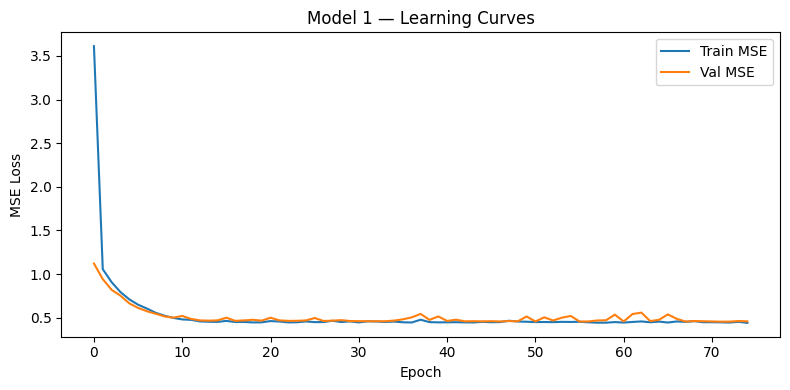

In [13]:
plot_losses(train_losses1, val_losses1, 'Model 1 — Learning Curves')

As can be seen, both curves drop quickly during the first epochs and then stabilize, staying close to each other throughout training. This suggests the model converges fast and does not show signs of overfitting,even without dropout

In [14]:
train_metrics = evaluate_model(model1, train_loader)
val_metrics   = evaluate_model(model1, val_loader)

metrics_df = pd.DataFrame({"Train": train_metrics, "Val": val_metrics})
metrics_df.T

,MAE,MSE,R²,RMSE
Train,0.474800,0.437861,0.672451,0.661711
Val,0.486578,0.458721,0.648049,0.677290


Train and validation performance are very similar, which suggests the model generalizes well given its limited capacity.This gives a reference point to compare with the next configurations.

## Model 2

Model 2 adds a third hidden layer and includes dropout of 0.2. This helps reduce overfitting by preventing the model from relying too much on specific patterns. The added depth allows it to capture more complex relationships in the data

In [15]:
torch.manual_seed(42)

model2 = HousingModel(
    hidden_sizes=[128, 64, 32],
    lower_bound=lower_bound,
    upper_bound=upper_bound,
    mean=mean,
    std=std,
    dropout=0.2,
)

print("Model 2")
train_losses2, val_losses2 = train_model(model2, train_loader, val_loader, lr=1e-3, epochs=100)

Model 2
  Epoch   1/100 | train MSE: 1.9588 | val MSE: 1.5800
  Epoch  25/100 | train MSE: 0.5308 | val MSE: 0.4872
  Epoch  50/100 | train MSE: 0.4631 | val MSE: 0.4304
  Epoch  75/100 | train MSE: 0.4352 | val MSE: 0.4021
  Epoch 100/100 | train MSE: 0.4225 | val MSE: 0.4014


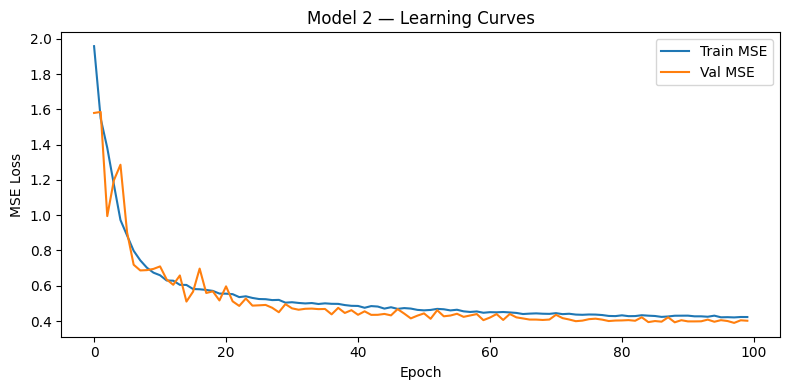

In [16]:
plot_losses(train_losses2, val_losses2, 'Model 2 — Learning Curves')

As can be seen, convergence is more gradual compared to Model 1, which is expected when using dropout. The validation loss stays close to the training loss without separating, suggesting the regularization is working and the model is not overfitting.

In [17]:
train_metrics = evaluate_model(model2, train_loader)
val_metrics   = evaluate_model(model2, val_loader)

metrics_df = pd.DataFrame({"Train": train_metrics, "Val": val_metrics})
metrics_df.T

,MAE,MSE,R²,RMSE
Train,0.435767,0.385035,0.711968,0.620512
Val,0.442265,0.401440,0.691998,0.633593


The val R^2 shows a clear improvement over Model 1, confirming that the added depth and dropout helped capture more complex patterns. the train/val gap remains small, meaning dropout at 0.2 was sufficient to control the overfitting

## Model 3

Model 3 tries something different by making the network wider, with 256 units in the first layer. A lower learning rate (5e-4) is used to make training more stable, with a larger model. Dropout is increased to 0.3 to help control overfitting. Since this configuration is more complex, it is trained for 150 epochs to have enoguh time to converge

In [18]:
torch.manual_seed(42)

model3 = HousingModel(
    hidden_sizes=[256, 128, 64],
    lower_bound=lower_bound,
    upper_bound=upper_bound,
    mean=mean,
    std=std,
    dropout=0.3,
)

print("Model 3")
train_losses3, val_losses3 = train_model(model3, train_loader, val_loader, lr=5e-4, epochs=150)

Model 3
  Epoch   1/150 | train MSE: 2.3263 | val MSE: 2.1743
  Epoch  25/150 | train MSE: 0.6119 | val MSE: 0.8962
  Epoch  50/150 | train MSE: 0.5227 | val MSE: 0.5397
  Epoch  75/150 | train MSE: 0.4900 | val MSE: 0.5054
  Epoch 100/150 | train MSE: 0.4539 | val MSE: 0.4323
  Epoch 125/150 | train MSE: 0.4305 | val MSE: 0.4114
  Epoch 150/150 | train MSE: 0.4257 | val MSE: 0.3963


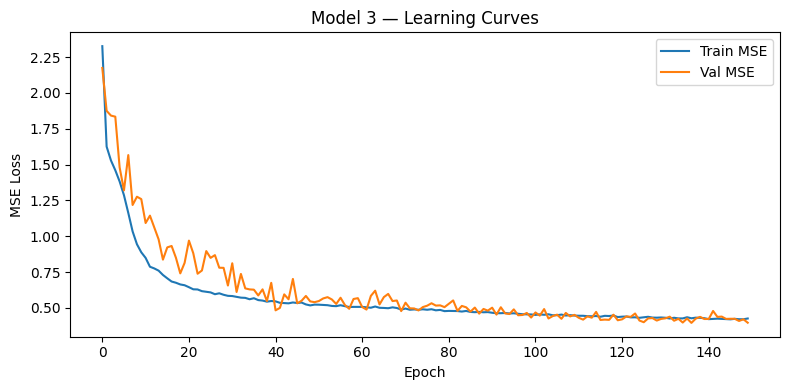

In [19]:
plot_losses(train_losses3, val_losses3, 'Model 3 — Learning Curves')

As can be seen, Model 3 has a stable training process. Both curves decrease over time,and the validation loss stays close to the training loss throughout the epochs.

In [20]:
train_metrics = evaluate_model(model3, train_loader)
val_metrics   = evaluate_model(model3, val_loader)

metrics_df = pd.DataFrame({"Train": train_metrics, "Val": val_metrics})
metrics_df.T

,MAE,MSE,R²,RMSE
Train,0.440436,0.382009,0.714232,0.618069
Val,0.448956,0.396339,0.695911,0.629555


Even though this model has the most parameters, the higher dropout and lower learning rate help keep overfitting under control,as seen in the small gap between training and validation.

## Model Comparison

The validation results of the three models are compared to make the selection clearer. R² is used as the main metric since it gives an idea of how well each model explains the target values.

In [21]:
configs = [
    'Model 1',
    'Model 2',
    'Model 3',
]

val_results = pd.DataFrame(
    [
        evaluate_model(model1, val_loader),
        evaluate_model(model2, val_loader),
        evaluate_model(model3, val_loader),
    ],
    index=configs
)
val_results.sort_values('R\u00b2', ascending=False)

,MAE,MSE,R²,RMSE
Model 3,0.448956,0.396339,0.695911,0.629555
Model 2,0.442265,0.401440,0.691998,0.633593
Model 1,0.486578,0.458721,0.648049,0.677290


## Final Evaluation — Best Model on Test Set

After selecting the best model using the validation set, it is evaluated once on the test set.

In [22]:
val_r2 = {
    'model1': evaluate_model(model1, val_loader)['R\u00b2'],
    'model2': evaluate_model(model2, val_loader)['R\u00b2'],
    'model3': evaluate_model(model3, val_loader)['R\u00b2'],
}
best_name  = max(val_r2, key=val_r2.get)
best_model = {'model1': model1, 'model2': model2, 'model3': model3}[best_name]

print(f"Best model: {best_name} (val R\u00b2 = {val_r2[best_name]:.4f})\n")

train_metrics = evaluate_model(best_model, train_loader)
test_metrics  = evaluate_model(best_model, test_loader)

metrics_df = pd.DataFrame({"Train": train_metrics, "Test": test_metrics})
metrics_df.T

Best model: model3 (val R² = 0.6959)



,MAE,MSE,R²,RMSE
Train,0.440436,0.382009,0.714232,0.618069
Test,0.438136,0.393410,0.701230,0.627224


The test results being close to the validation results suggest that the model generalizes well and was not overfitted to the validation set. The small gap between training and test performance is expected given the number of training epochs.

## Personal Reflection

This activity made the difference between the two preprocessing approaches much clearer. Before, preprocessing was done outside the model using sklearn, which works fine but requires keeping track of extra objects separately. Here, preprocessing is part of the model itself, so is easier to manage.

Including preprocessing inside "nn.Module" makes the model more consistent, since the same transformations are always applied without depending on anything external. 

Comparing the different models also helped show the importance of looking beyond just performance values. Checking how close the train and validation results are gives a better idea of whether the model is learning properly or if it is too simple or too complex.